# Class Imbalance Analysis | Titanic Dataset

**Content:**

1. Load data and establish baseline
2. Apply resampling techniques (oversampling, SMOTE, undersampling, class weights)
3. Compare impact on classification metrics
4. Key takeaways

## 1. Load Data and Establish Baseline

Load the engineered features from `03_feature_engineering.ipynb` and train a baseline Logistic Regression without any imbalance handling.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier

from titanic_ml.models import ModelRegistry
from titanic_ml.evaluation import compute_metrics

%matplotlib inline

SEED = 42

# Load engineered features
X_all = pd.read_csv("../data/train_engineered.csv")
y_all = pd.read_csv("../data/y_train.csv").squeeze()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

# Class distribution
print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")
print(f"Train class distribution: {y_train.value_counts().to_dict()}")
print(f"Train survived rate: {y_train.mean():.1%}")

Train: 711 rows, Test: 178 rows
Train class distribution: {0.0: 439, 1.0: 272}
Train survived rate: 38.3%


In [7]:
# Dummy classifier — always predicts majority class
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)
dummy_metrics = compute_metrics(y_test, dummy.predict(X_test))

# Baselines — each model without any imbalance handling
baseline_configs = {
    "LR": ("logistic_regression", {"max_iter": 1000}),
    "RF": ("random_forest", {"n_estimators": 100}),
    "GBM": ("gradient_boosting", {"n_estimators": 100}),
}

# results is a dict of dicts: {model_label: {technique_name: metrics_dict}}
results = {}
baselines = {}  # keep model objects for confusion matrices later

for label, (mtype, mhp) in baseline_configs.items():
    m = ModelRegistry(mtype, hyperparams=mhp, random_seed=SEED)
    m.train(X_train, y_train)
    baselines[label] = m
    bm = compute_metrics(y_test, m.predict(X_test))
    results[label] = {"Dummy (majority)": dummy_metrics, f"Baseline {label}": bm}

for label, techs in results.items():
    print(f"--- {label} ---")
    for name, m in techs.items():
        print(f"  {name:25s}  acc={m['accuracy']:.4f}  prec={m['precision']:.4f}  rec={m['recall']:.4f}  f1={m['f1']:.4f}")

--- LR ---
  Dummy (majority)           acc=0.6180  prec=0.0000  rec=0.0000  f1=0.0000
  Baseline LR                acc=0.8202  prec=0.8000  rec=0.7059  f1=0.7500
--- RF ---
  Dummy (majority)           acc=0.6180  prec=0.0000  rec=0.0000  f1=0.0000
  Baseline RF                acc=0.7697  prec=0.7213  rec=0.6471  f1=0.6822
--- GBM ---
  Dummy (majority)           acc=0.6180  prec=0.0000  rec=0.0000  f1=0.0000
  Baseline GBM               acc=0.8371  prec=0.8095  rec=0.7500  f1=0.7786


## 2. Resampling Techniques

We apply four techniques to the training data and evaluate each with three classifiers: i) Logistic Regression, ii) Random Forest, and iii) Gradient Boosting. Assumption is that different model families respond differently to class imbalance: tree-based models (RF, GBM) might be particularly sensitive because they optimise for overall accuracy by default, whereas LR's loss function is more naturally amenable to reweighting.

In [ ]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

techniques = {
    "Random Oversampling": RandomOverSampler(random_state=SEED),
    "SMOTE": SMOTE(random_state=SEED),
    "Random Undersampling": RandomUnderSampler(random_state=SEED),
}

# Models to compare — LR, RF, GBM
model_configs = {
    "LR": ("logistic_regression", {"max_iter": 1000}),
    "RF": ("random_forest", {"n_estimators": 100}),
    "GBM": ("gradient_boosting", {"n_estimators": 100}),
}

for model_label, (model_type, model_hp) in model_configs.items():
    # Resampling techniques
    for name, sampler in techniques.items():
        X_res, y_res = sampler.fit_resample(X_train, y_train)
        model = ModelRegistry(model_type, hyperparams=model_hp, random_seed=SEED)
        model.train(X_res, y_res)
        metrics = compute_metrics(y_test, model.predict(X_test))
        results[model_label][name] = metrics
        print(f"{name + ' (' + model_label + ')':40s}  train_size={len(y_res):4d} ({y_res.mean():.0%} survived)  "
              f"acc={metrics['accuracy']:.4f}  prec={metrics['precision']:.4f}  rec={metrics['recall']:.4f}  f1={metrics['f1']:.4f}")

    # Class weights (no resampling — modifies loss function)
    # GradientBoostingClassifier doesn't support class_weight natively, so we skip it.
    if model_type not in {'logistic_regression', 'random_forest'}:
        print(f"{'Class Weights (' + model_label + ')':40s}  skipped — {model_label} does not support class_weight")
        print()
        continue
    cw_hp = {**model_hp, "class_weight": "balanced"}
    cw_model = ModelRegistry(model_type, hyperparams=cw_hp, random_seed=SEED)
    cw_model.train(X_train, y_train)
    cw_metrics = compute_metrics(y_test, cw_model.predict(X_test))
    results[model_label]["Class Weights"] = cw_metrics
    print(f"{'Class Weights (' + model_label + ')':40s}  train_size={len(y_train):4d} (original)       "
          f"acc={cw_metrics['accuracy']:.4f}  prec={cw_metrics['precision']:.4f}  rec={cw_metrics['recall']:.4f}  f1={cw_metrics['f1']:.4f}")
    print()

Random Oversampling (LR)                  train_size= 878 (50% survived)  acc=0.8202  prec=0.7727  rec=0.7500  f1=0.7612
SMOTE (LR)                                train_size= 878 (50% survived)  acc=0.8315  prec=0.8065  rec=0.7353  f1=0.7692
Random Undersampling (LR)                 train_size= 544 (50% survived)  acc=0.8202  prec=0.7500  rec=0.7941  f1=0.7714
Class Weights (LR)                        train_size= 711 (original)       acc=0.8315  prec=0.7794  rec=0.7794  f1=0.7794

Random Oversampling (RF)                  train_size= 878 (50% survived)  acc=0.7753  prec=0.7121  rec=0.6912  f1=0.7015
SMOTE (RF)                                train_size= 878 (50% survived)  acc=0.7809  prec=0.7164  rec=0.7059  f1=0.7111
Random Undersampling (RF)                 train_size= 544 (50% survived)  acc=0.7584  prec=0.6667  rec=0.7353  f1=0.6993
Class Weights (RF)                        train_size= 711 (original)       acc=0.7865  prec=0.7273  rec=0.7059  f1=0.7164

Random Oversampling (GBM)   

## 3. Comparison

Side-by-side comparison of all techniques across all three model families.


LR


,Accuracy,Precision,Recall,F1
Technique,,,,
Dummy (majority),0.6180,0.0000,0.0000,0.0000
Baseline LR,0.8202,0.8000,0.7059,0.7500
Random Oversampling,0.8202,0.7727,0.7500,0.7612
SMOTE,0.8315,0.8065,0.7353,0.7692
Random Undersampling,0.8202,0.7500,0.7941,0.7714
Class Weights,0.8315,0.7794,0.7794,0.7794



RF


,Accuracy,Precision,Recall,F1
Technique,,,,
Dummy (majority),0.6180,0.0000,0.0000,0.0000
Baseline RF,0.7697,0.7213,0.6471,0.6822
Random Oversampling,0.7753,0.7121,0.6912,0.7015
SMOTE,0.7809,0.7164,0.7059,0.7111
Random Undersampling,0.7584,0.6667,0.7353,0.6993
Class Weights,0.7865,0.7273,0.7059,0.7164



GBM


,Accuracy,Precision,Recall,F1
Technique,,,,
Dummy (majority),0.6180,0.0000,0.0000,0.0000
Baseline GBM,0.8371,0.8095,0.7500,0.7786
Random Oversampling,0.8034,0.7391,0.7500,0.7445
SMOTE,0.8371,0.7910,0.7794,0.7852
Random Undersampling,0.7978,0.7162,0.7794,0.7465


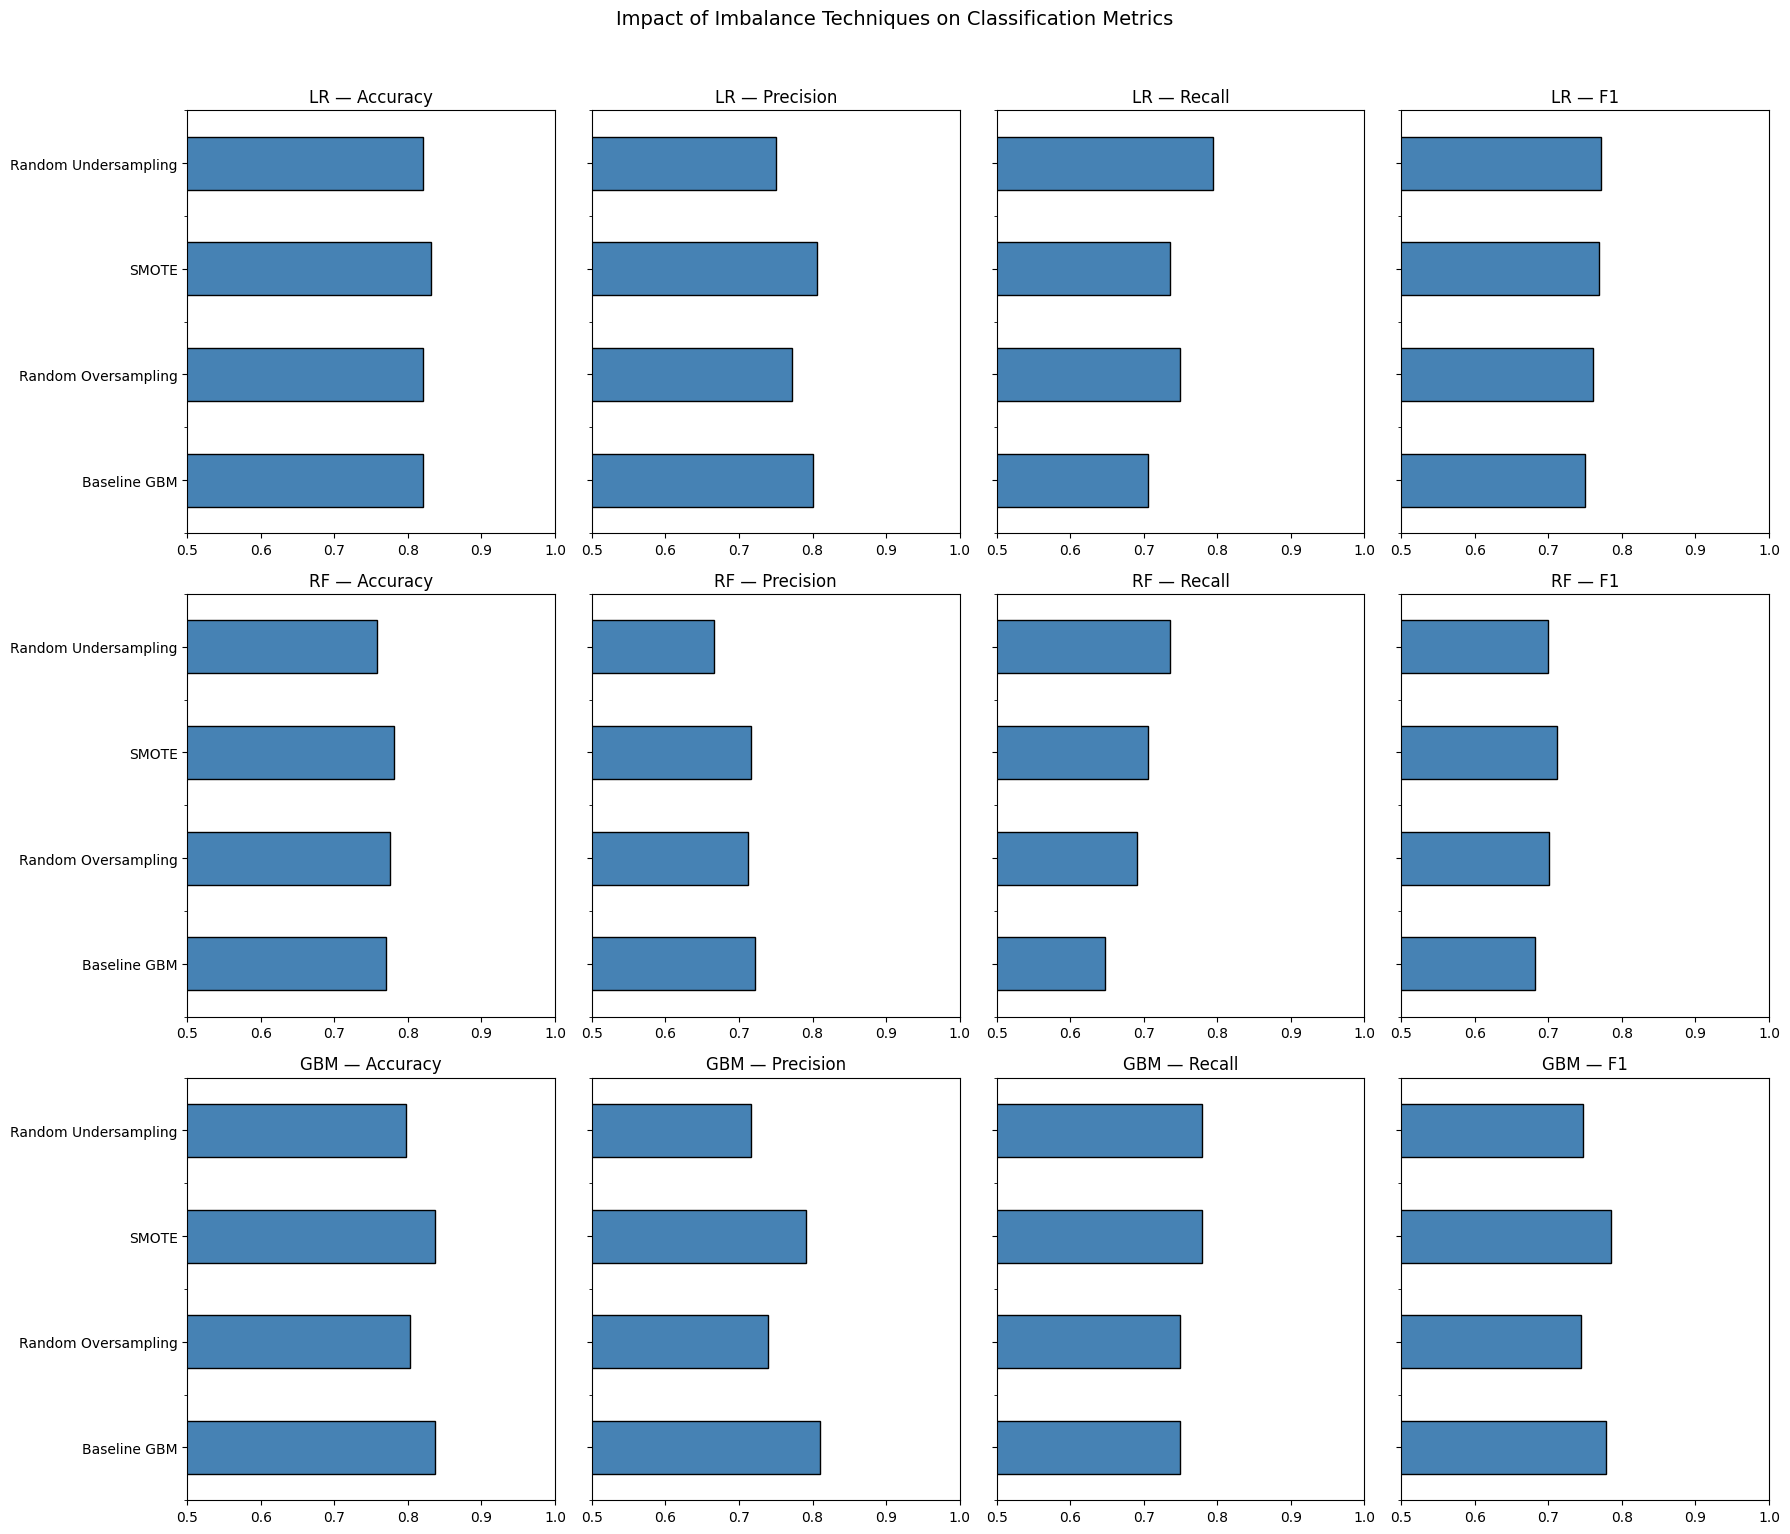

In [9]:
# One comparison table per model, each with green highlights on column maxima
for model_label, techs in results.items():
    comp_df = pd.DataFrame(techs).T
    comp_df.columns = [c.capitalize() for c in comp_df.columns]
    comp_df.index.name = "Technique"
    print(f"\n{model_label}")
    display(comp_df.style.format("{:.4f}").highlight_max(axis=0, color="lightgreen"))

# Visual comparison — one row of bar charts per model
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]
n_models = len(results)
fig, axes = plt.subplots(n_models, 4, figsize=(18, 5 * n_models), sharey=True)
if n_models == 1:
    axes = [axes]  # ensure 2-D indexing

for row_idx, (model_label, techs) in enumerate(results.items()):
    plot_df = pd.DataFrame(techs).T
    plot_df.columns = [c.capitalize() for c in plot_df.columns]
    plot_df = plot_df.drop(index="Dummy (majority)", errors="ignore")[metrics_to_plot]
    for col_idx, metric in enumerate(metrics_to_plot):
        plot_df[metric].plot(kind="barh", ax=axes[row_idx][col_idx], color="steelblue", edgecolor="black")
        axes[row_idx][col_idx].set_title(f"{model_label} — {metric}")
        axes[row_idx][col_idx].set_xlim(0.5, 1.0)

fig.suptitle("Impact of Imbalance Techniques on Classification Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

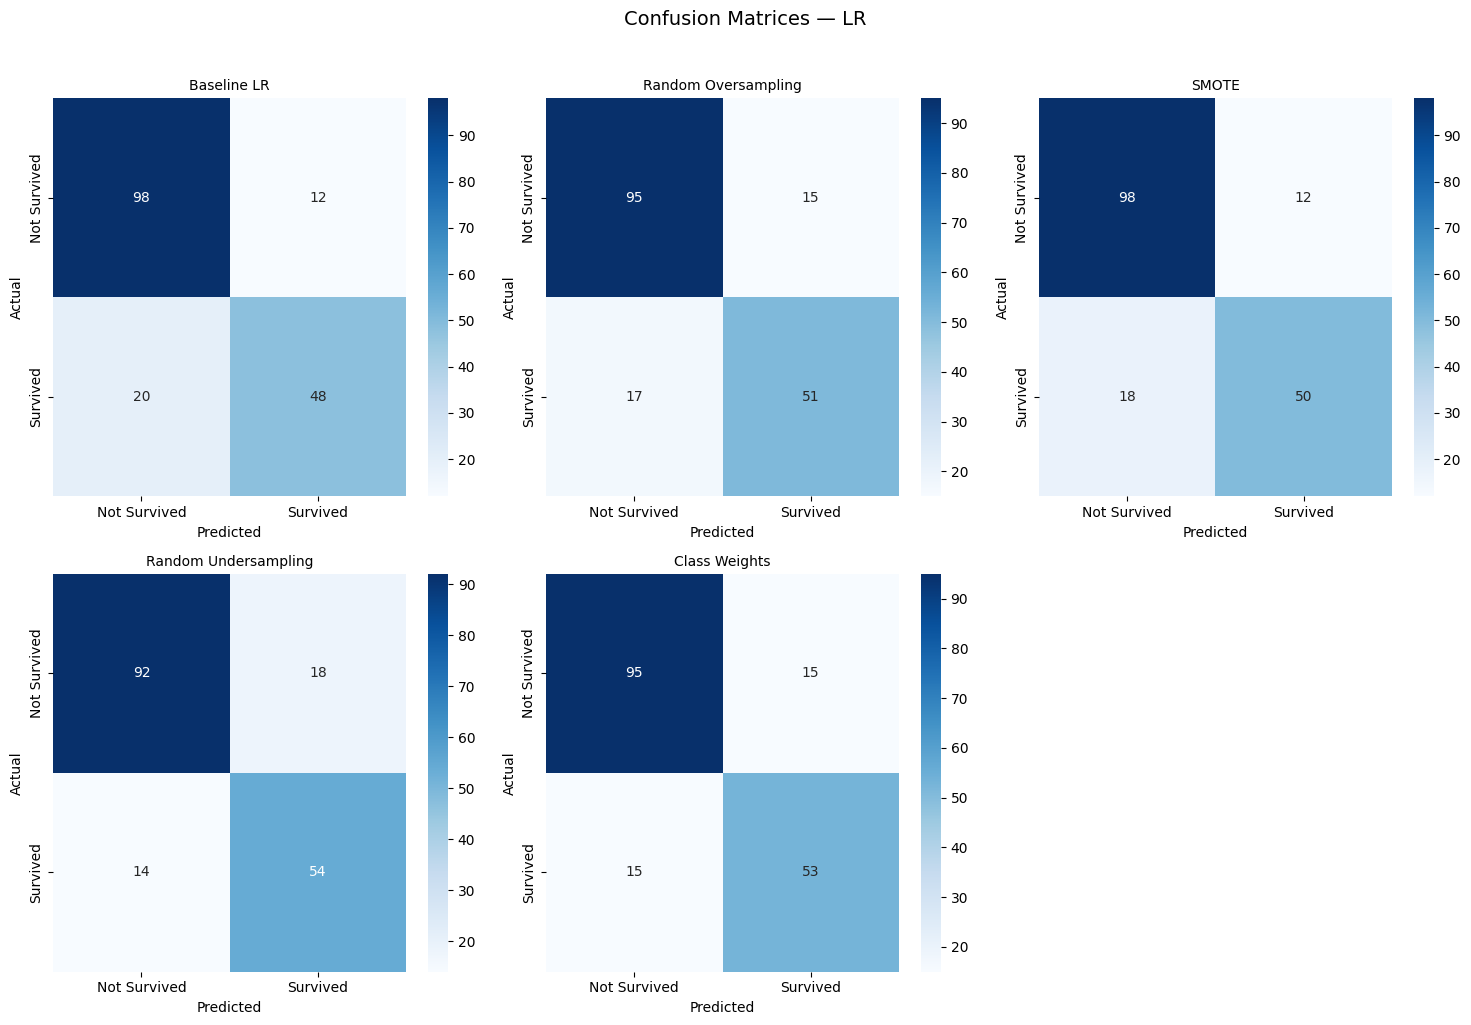

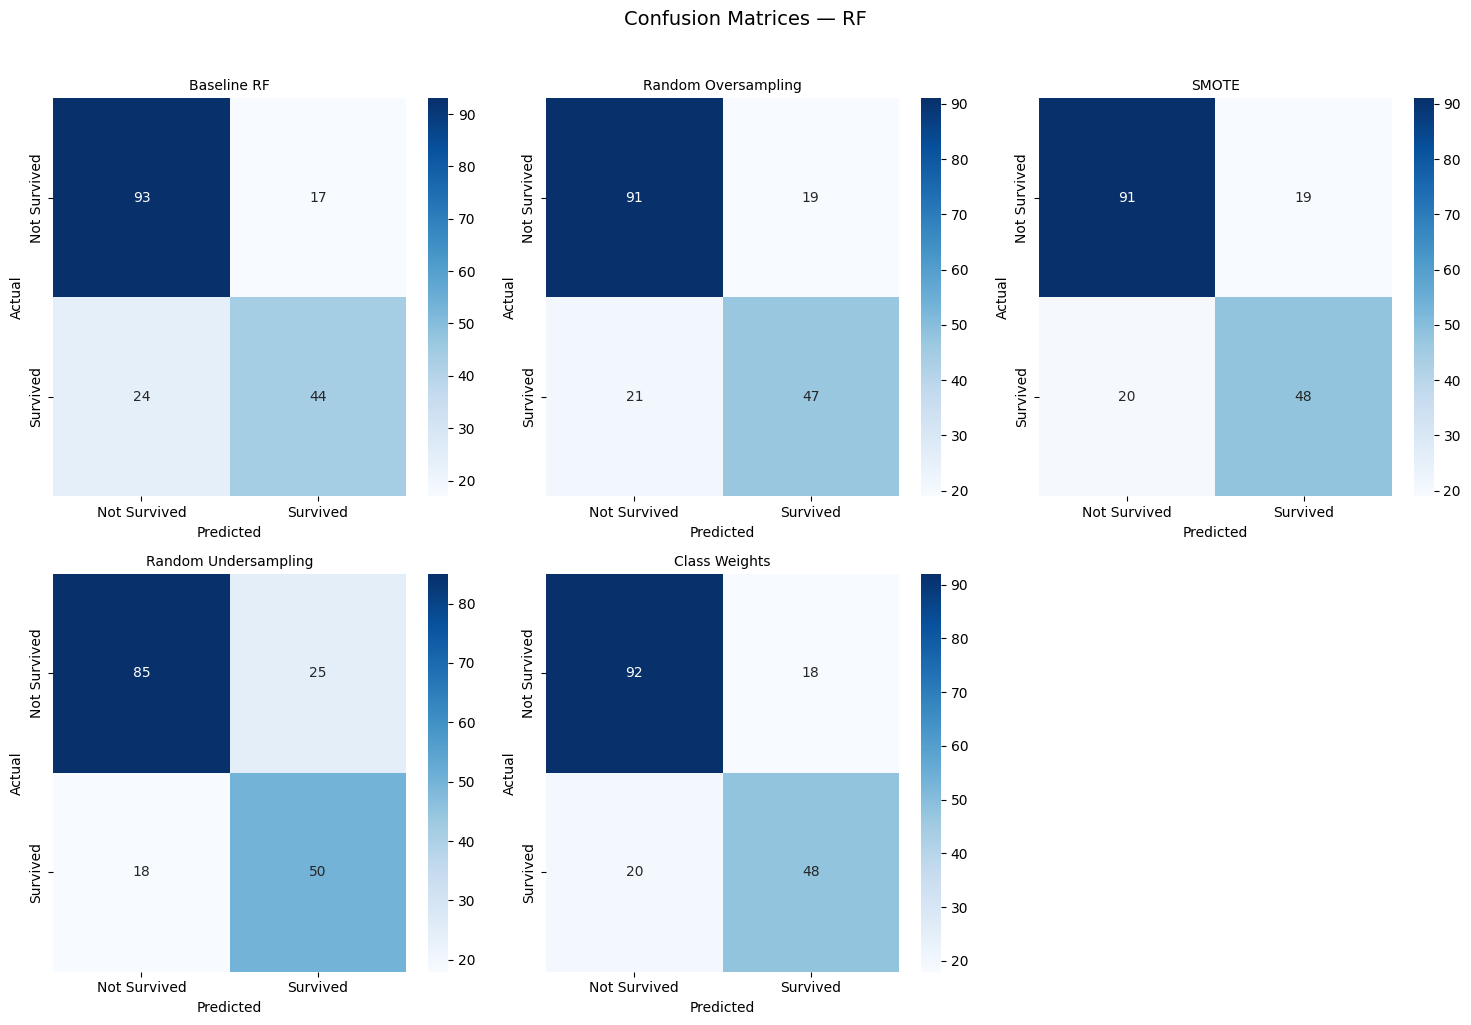

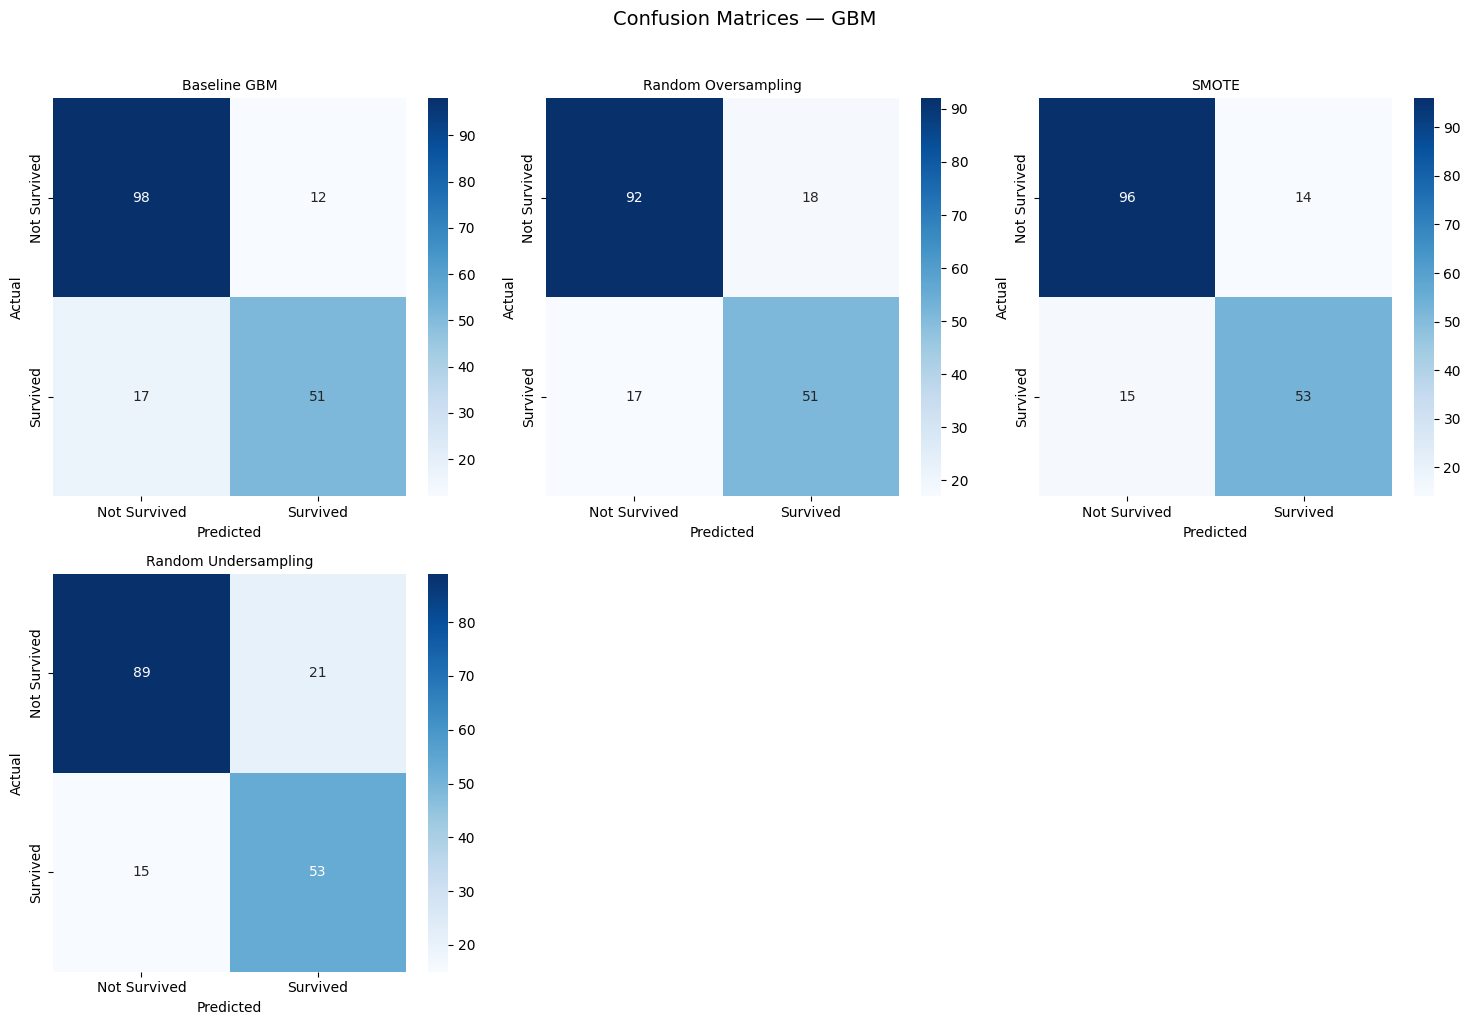

In [10]:
# Confusion matrices — one grid per model
for model_label, (model_type, model_hp) in model_configs.items():
    technique_models = {f"Baseline {model_label}": baselines[model_label]}
    for name, sampler in techniques.items():
        X_res, y_res = sampler.fit_resample(X_train, y_train)
        m = ModelRegistry(model_type, hyperparams=model_hp, random_seed=SEED)
        m.train(X_res, y_res)
        technique_models[name] = m
    if model_type in {'logistic_regression', 'random_forest'}:
        cw_hp = {**model_hp, "class_weight": "balanced"}
        cw_m = ModelRegistry(model_type, hyperparams=cw_hp, random_seed=SEED)
        cw_m.train(X_train, y_train)
        technique_models["Class Weights"] = cw_m

    names = list(technique_models.keys())
    ncols = 3
    nrows = (len(names) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
    axes = axes.flatten()

    for idx, name in enumerate(names):
        preds = technique_models[name].predict(X_test)
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Not Survived", "Survived"],
                    yticklabels=["Not Survived", "Survived"],
                    ax=axes[idx])
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")
        axes[idx].set_title(name, fontsize=10)

    for idx in range(len(names), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(f"Confusion Matrices — {model_label}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

Note:
- Tree-based models (RF, GBM) tend to benefit more from imbalance mitigation than LR does, aligned with initial expectation. 
- Class Weights is effective across all three model families. It adjusts the loss function without altering the training data, which avoids overfitting risks from oversampling.
- Random Undersampling remains the most aggressive technique: it maximises recall but deteriorates tree-based models overall performances that rely on large sample sizes for stable splits.